In [1]:
import pandas as pd
import numpy as np

orders = pd.read_csv(
    '../01-data/processed/cleaned_orders.csv'
)

orders['created_at'] = pd.to_datetime(
    orders['created_at'],
    format='mixed',
    utc=True
)

orders['order_month'] = (
    orders['created_at']
    .dt.to_period('M')
)

C:\Users\OM\AppData\Local\Temp\ipykernel_12084\1436740655.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


In [2]:
user_months = (

    orders
    .groupby(
        ['user_id','order_month']
    )
    .size()
    .reset_index(name='orders')

)

user_months.head()

,user_id,order_month,orders
0,1,2022-07,1
1,2,2022-02,1
2,3,2023-03,1
3,3,2023-04,2
4,3,2023-08,1


In [3]:
first_month = (

    user_months
    .groupby('user_id')['order_month']
    .min()
    .reset_index()

)

first_month.columns = [
    'user_id',
    'first_month'
]

user_months = user_months.merge(
    first_month,
    on='user_id'
)

user_months['is_new'] = (
    user_months['order_month']
    ==
    user_months['first_month']
)

In [4]:
months = sorted(
    user_months['order_month'].unique()
)

growth_results = []

for i in range(1,len(months)):

    current = months[i]
    previous = months[i-1]

    current_users = set(

        user_months[
            user_months['order_month']==current
        ]['user_id']

    )

    previous_users = set(

        user_months[
            user_months['order_month']==previous
        ]['user_id']

    )

    new_users = set(

        user_months[
            (user_months['order_month']==current)
            &
            (user_months['is_new'])
        ]['user_id']

    )

    retained = (
        current_users
        &
        previous_users
    )

    churned = (
        previous_users
        -
        current_users
    )

    resurrected = (
        current_users
        -
        retained
        -
        new_users
    )

    growth_results.append([

        str(current),

        len(new_users),

        len(retained),

        len(resurrected),

        len(churned)

    ])

In [5]:
growth_accounting = pd.DataFrame(

    growth_results,

    columns=[
        'month',
        'new_users',
        'retained_users',
        'resurrected_users',
        'churned_users'
    ]

)

growth_accounting['net_growth'] = (

    growth_accounting['new_users']

    +

    growth_accounting['resurrected_users']

    -

    growth_accounting['churned_users']

)

growth_accounting.head()

,month,new_users,retained_users,resurrected_users,churned_users,net_growth
0,2019-02,37,0,0,22,15
1,2019-03,83,0,1,37,47
2,2019-04,103,1,0,83,20
3,2019-05,164,2,0,102,62
4,2019-06,188,1,4,165,27


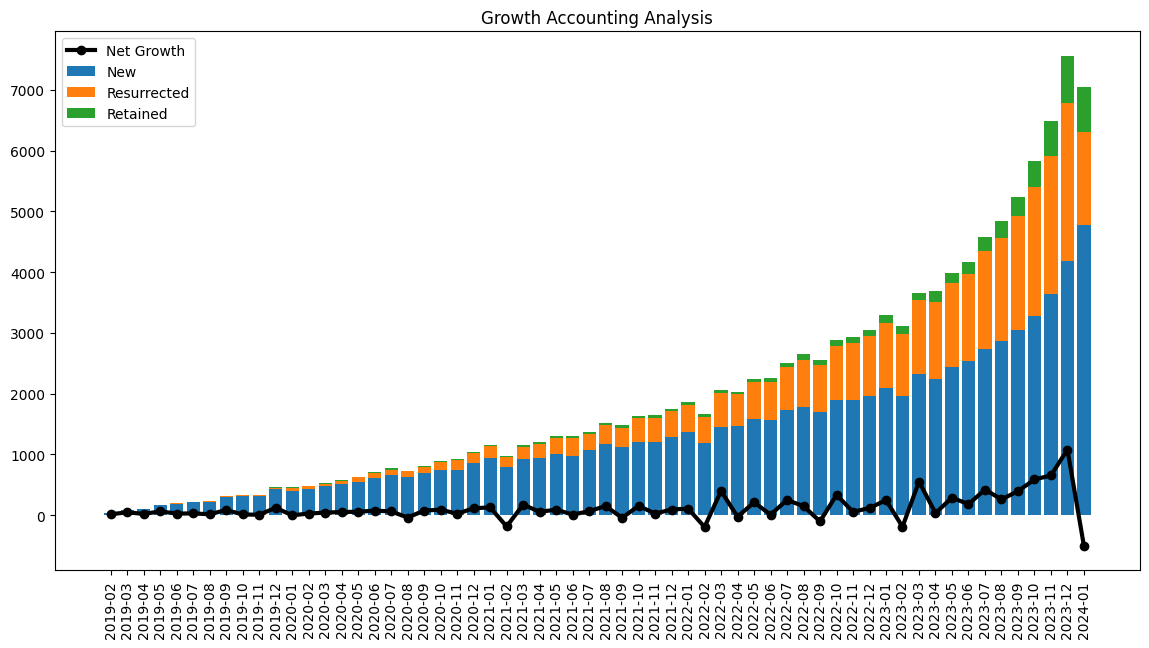

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,7))

plt.bar(
    growth_accounting['month'],
    growth_accounting['new_users'],
    label='New'
)

plt.bar(
    growth_accounting['month'],
    growth_accounting['resurrected_users'],
    bottom=growth_accounting['new_users'],
    label='Resurrected'
)

plt.bar(
    growth_accounting['month'],
    growth_accounting['retained_users'],
    bottom=
    growth_accounting['new_users']
    +
    growth_accounting['resurrected_users'],
    label='Retained'
)

plt.plot(
    growth_accounting['month'],
    growth_accounting['net_growth'],
    color='black',
    linewidth=3,
    marker='o',
    label='Net Growth'
)

plt.xticks(rotation=90)

plt.legend()

plt.title(
    'Growth Accounting Analysis'
)

plt.show()

In [9]:
growth_accounting.to_csv(
    'growth_accounting.csv',
    index=False
)

In [12]:
import os

os.makedirs('../outputs', exist_ok=True)

print("Outputs folder created")

Outputs folder created


In [13]:
import json

kpi_tree = {
    "North_Star_Metric": "Weekly Active Buyers",
    "Level_1": {
        "MAU": [
            "New Users",
            "Retained Users",
            "Resurrected Users"
        ],
        "Conversion Rate": [
            "Product Views",
            "Cart Adds",
            "Purchases"
        ],
        "Repeat Purchase Rate": [
            "Retention",
            "Loyalty",
            "Customer Experience"
        ]
    }
}

with open('../outputs/kpi_tree_data.json', 'w') as f:
    json.dump(kpi_tree, f, indent=4)

print("kpi_tree_data.json saved successfully")

kpi_tree_data.json saved successfully


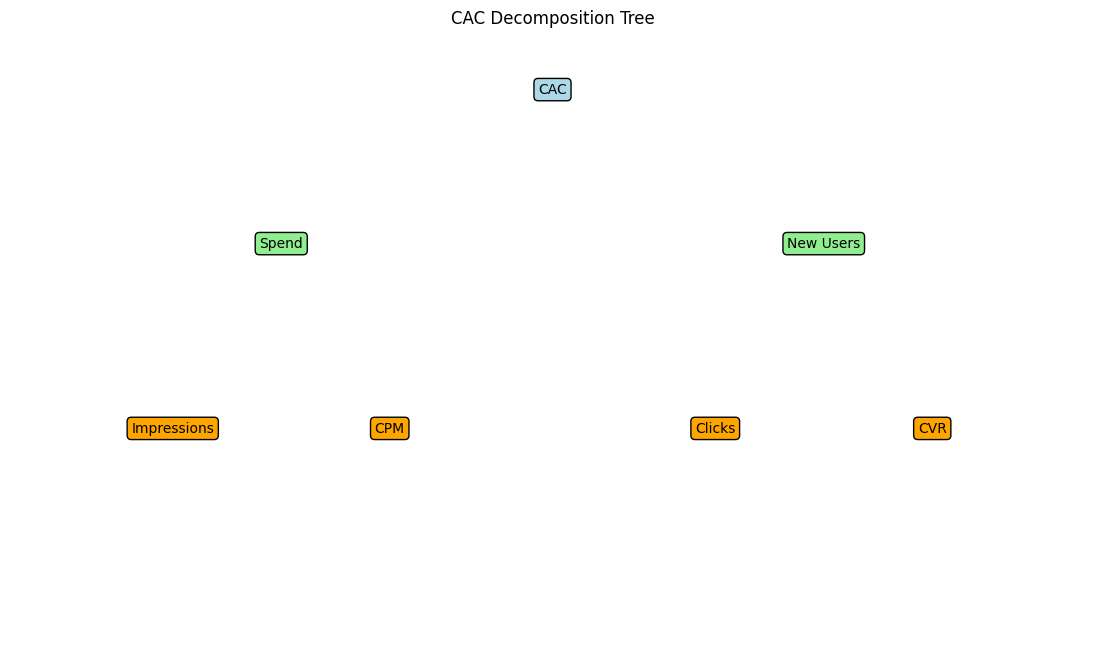

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(14,8)
)

ax.axis('off')

ax.text(
    0.50,0.90,'CAC',
    ha='center',
    bbox=dict(boxstyle='round',fc='lightblue')
)

ax.text(
    0.25,0.65,'Spend',
    ha='center',
    bbox=dict(boxstyle='round',fc='lightgreen')
)

ax.text(
    0.75,0.65,'New Users',
    ha='center',
    bbox=dict(boxstyle='round',fc='lightgreen')
)

ax.text(
    0.15,0.35,'Impressions',
    ha='center',
    bbox=dict(boxstyle='round',fc='orange')
)

ax.text(
    0.35,0.35,'CPM',
    ha='center',
    bbox=dict(boxstyle='round',fc='orange')
)

ax.text(
    0.65,0.35,'Clicks',
    ha='center',
    bbox=dict(boxstyle='round',fc='orange')
)

ax.text(
    0.85,0.35,'CVR',
    ha='center',
    bbox=dict(boxstyle='round',fc='orange')
)

plt.title("CAC Decomposition Tree")

plt.show()

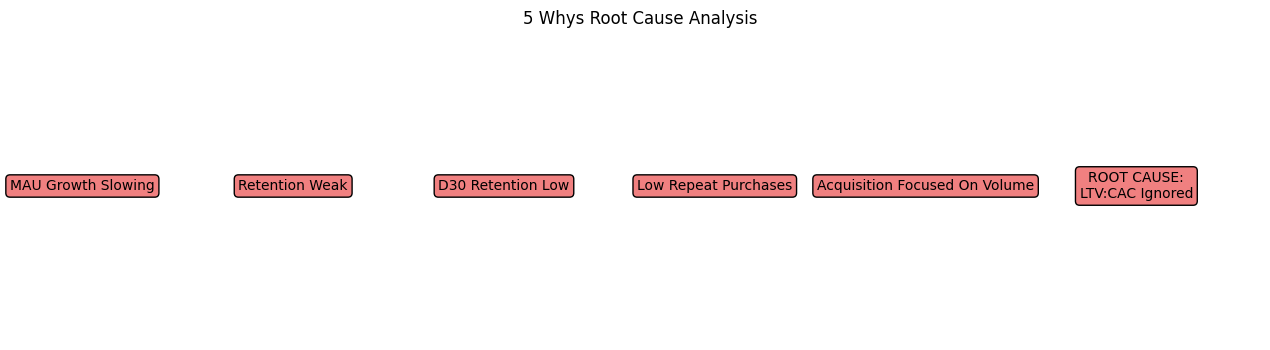

In [15]:
fig, ax = plt.subplots(
    figsize=(16,4)
)

ax.axis('off')

whys = [

"MAU Growth Slowing",

"Retention Weak",

"D30 Retention Low",

"Low Repeat Purchases",

"Acquisition Focused On Volume",

"ROOT CAUSE:\nLTV:CAC Ignored"

]

positions = [
0.05,
0.22,
0.39,
0.56,
0.73,
0.90
]

for pos,text in zip(
    positions,
    whys
):

    ax.text(
        pos,
        0.5,
        text,
        ha='center',
        va='center',
        bbox=dict(
            boxstyle='round',
            fc='lightcoral'
        )
    )

plt.title(
    "5 Whys Root Cause Analysis"
)

plt.show()

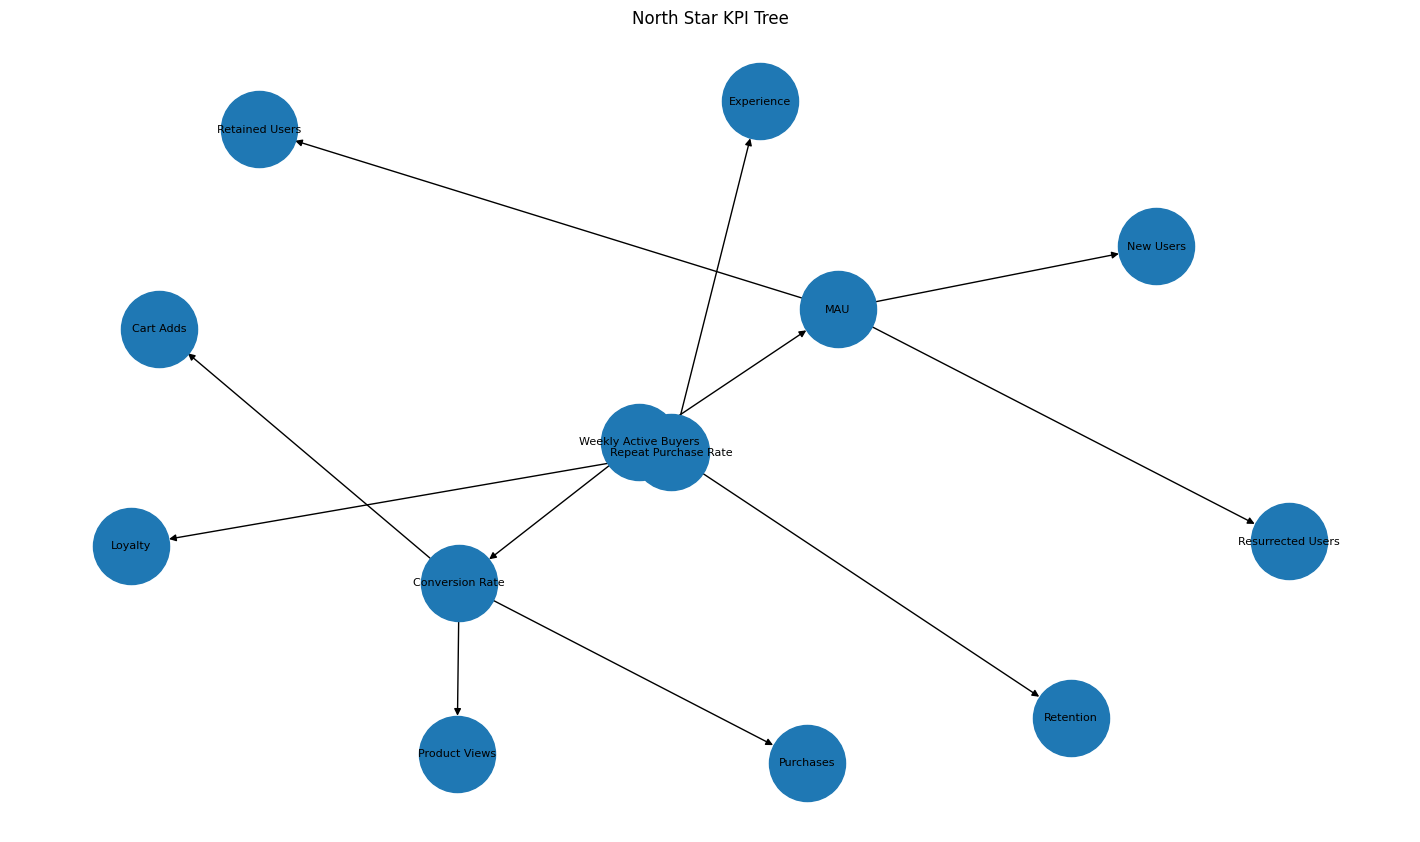

In [16]:
import networkx as nx

G = nx.DiGraph()

edges = [

('Weekly Active Buyers','MAU'),
('Weekly Active Buyers','Conversion Rate'),
('Weekly Active Buyers','Repeat Purchase Rate'),

('MAU','New Users'),
('MAU','Retained Users'),
('MAU','Resurrected Users'),

('Conversion Rate','Product Views'),
('Conversion Rate','Cart Adds'),
('Conversion Rate','Purchases'),

('Repeat Purchase Rate','Retention'),
('Repeat Purchase Rate','Loyalty'),
('Repeat Purchase Rate','Experience')

]

G.add_edges_from(edges)

plt.figure(
    figsize=(14,8)
)

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=8
)

plt.title(
    "North Star KPI Tree"
)

plt.show()

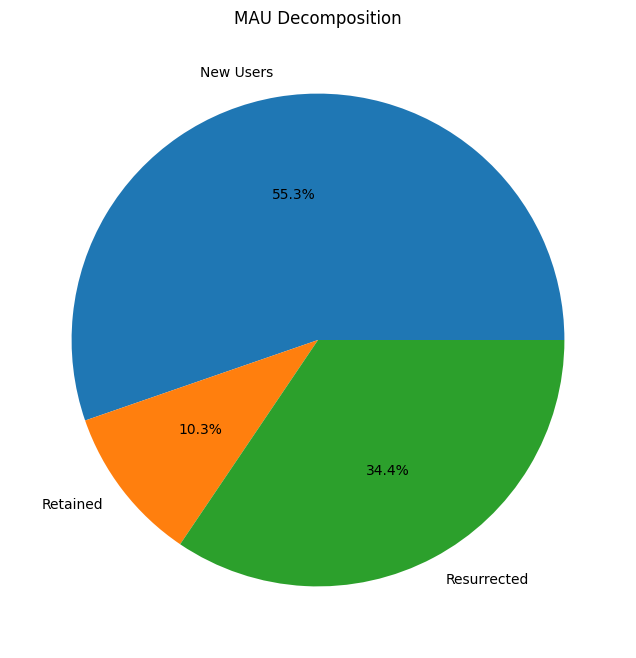

In [17]:
latest = growth_accounting.iloc[-2]

plt.figure(
    figsize=(8,8)
)

plt.pie(

    [

        latest['new_users'],
        latest['retained_users'],
        latest['resurrected_users']

    ],

    labels=[

        'New Users',
        'Retained',
        'Resurrected'

    ],

    autopct='%1.1f%%'

)

plt.title(
    'MAU Decomposition'
)

plt.show()

In [20]:
import pandas as pd

cac_df = pd.DataFrame({

    'traffic_source': [
        'Display',
        'Email',
        'Facebook',
        'Organic',
        'Search'
    ],

    'avg_ltv': [
        107.743065,
        106.823487,
        107.870686,
        108.369935,
        108.415877
    ],

    'cac': [
        0,
        160.703457,
        1788.170564,
        355.393779,
        199.072422
    ],

    'ltv_cac_ratio': [
        0,
        0.664724,
        0.060325,
        0.304929,
        0.544605
    ]

})

cac_df

,traffic_source,avg_ltv,cac,ltv_cac_ratio
0,Display,107.743065,0.000000,0.000000
1,Email,106.823487,160.703457,0.664724
2,Facebook,107.870686,1788.170564,0.060325
3,Organic,108.369935,355.393779,0.304929
4,Search,108.415877,199.072422,0.544605


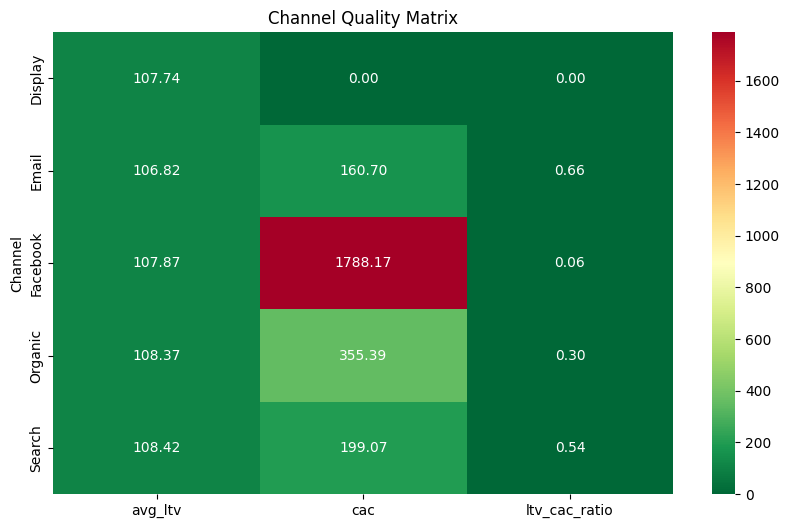

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

quality = cac_df.set_index('traffic_source')

plt.figure(figsize=(10,6))

sns.heatmap(
    quality[['avg_ltv','cac','ltv_cac_ratio']],
    annot=True,
    cmap='RdYlGn_r',
    fmt='.2f'
)

plt.title('Channel Quality Matrix')
plt.ylabel('Channel')
plt.show()